In [12]:
#!/usr/bin/env python3

from bioblend.galaxy import GalaxyInstance
import pandas as pd
import io
import os
import sys
from pathlib import Path
from dotenv import load_dotenv

# === CONFIGURATION ===
load_dotenv(dotenv_path="../.env")

GALAXY_URL = "https://usegalaxy.eu"
API_KEY = os.getenv("GALAXY_API")

if not API_KEY:
    sys.exit("❌ GALAXY_API environment variable not set")

In [13]:
gi = GalaxyInstance(url='https://usegalaxy.eu/', key=API_KEY)

# Optional: output directory
OUTPUT_DIR = Path("input")
OUTPUT_DIR.mkdir(exist_ok=True)

history_id = '11ac94870d0bb33aa68dfe028a76436a'

# ✅ New tags
target_tags = {
    'semibin-single-sample-binning',
    'semibin-multi-sample-binning',
    'comebin-multi-sample-binning',
}

dfs = []

history_contents = gi.histories.show_history(history_id, contents=True)

for item in history_contents:
    if item['type'] == 'collection':
        collection_id = item['id']
        collection_info = gi.dataset_collections.show_dataset_collection(collection_id)

        # 🔽 Find matching tag
        matching_tags = [tag for tag in collection_info['tags'] if tag in target_tags]

        if matching_tags:
            matched_tag = matching_tags[0]  # assuming one relevant tag per collection

            for dataset in collection_info['elements']:
                dataset_id = dataset['object']['id']
                filename = dataset['element_identifier']

                # Download dataset content
                content = gi.datasets.download_dataset(
                    dataset_id,
                    file_path=None,
                    use_default_filename=False
                )

                # Load TSV into DataFrame
                df = pd.read_csv(io.StringIO(content.decode("utf-8")), sep="\t")

                # Keep provenance
                df["source_dataset"] = filename
                df["collection"] = collection_info["name"]
                df["tag"] = matched_tag  # ✅ NEW COLUMN

                dfs.append(df)

# Combine all
final_df = pd.concat(dfs, ignore_index=True)

print(final_df)

           Name  Completeness  Contamination          Completeness_Model_Used  \
0     SemiBin_0         13.27           0.53  Neural Network (Specific Model)   
1    SemiBin_10         70.80          10.21  Neural Network (Specific Model)   
2    SemiBin_11         72.71          34.25  Neural Network (Specific Model)   
3    SemiBin_14         16.93           0.01  Neural Network (Specific Model)   
4    SemiBin_18          4.42           0.11  Neural Network (Specific Model)   
..          ...           ...            ...                              ...   
210     6584.fa         92.56           3.65   Gradient Boost (General Model)   
211     7416.fa         18.02           1.68  Neural Network (Specific Model)   
212     7735.fa         11.12           1.66  Neural Network (Specific Model)   
213     8037.fa         57.16          29.60  Neural Network (Specific Model)   
214     9713.fa         13.97           3.77  Neural Network (Specific Model)   

     Translation_Table_Used

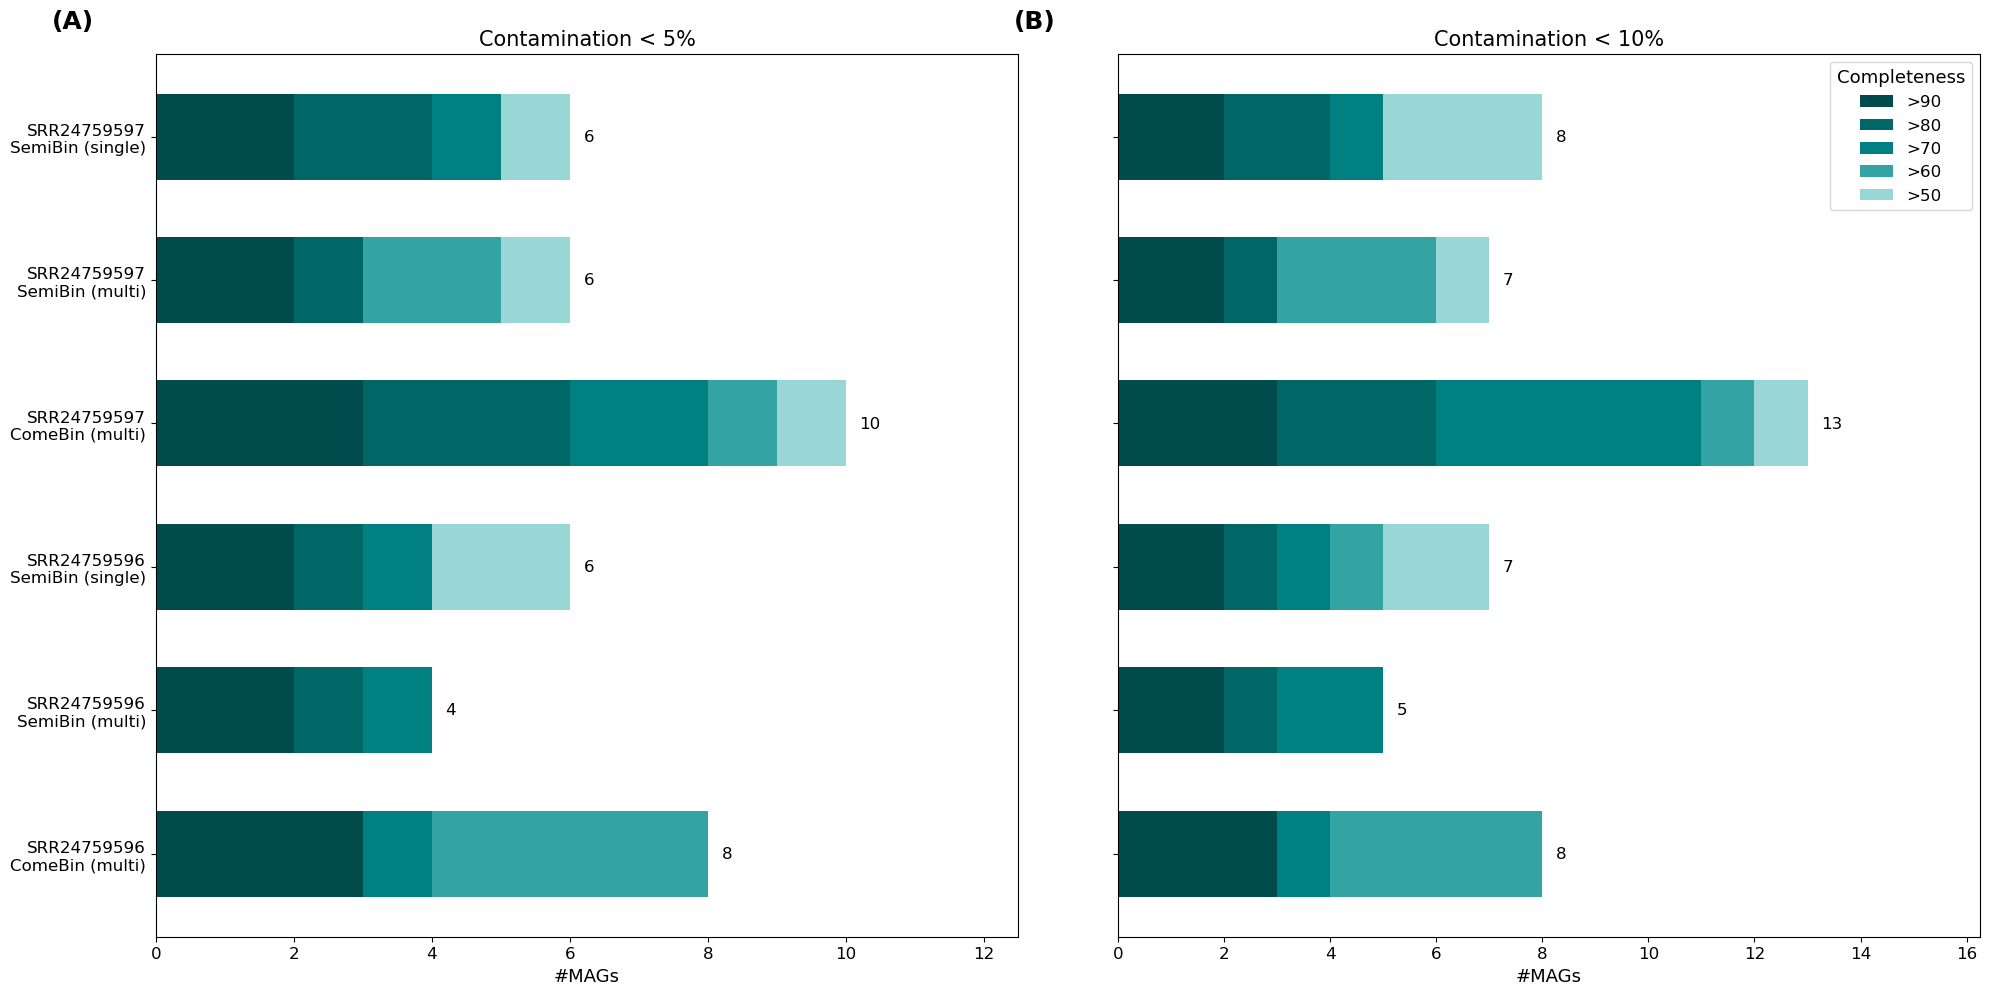

In [14]:
import numpy as np
import matplotlib.pyplot as plt
import re

thresholds = [">90", ">80", ">70", ">60", ">50"]
colors = ["#004c4c", "#006666", "#008080", "#33a3a3", "#99d6d6"]

def assign_threshold(comp):
    if comp >= 90:
        return ">90"
    elif comp >= 80:
        return ">80"
    elif comp >= 70:
        return ">70"
    elif comp >= 60:
        return ">60"
    elif comp >= 50:
        return ">50"
    return None

def natural_key(s):
    """Convert string to int when possible for natural sorting."""
    return int(s) if s.isdigit() else s

def load_counts_from_df(df, cont_cutoff):
    result = {thr: [] for thr in thresholds}
    labels = []

    grouped = df.groupby(["source_dataset", "tag"])

    for (sample, method), g in grouped:
        df2 = g[g["Contamination"] < cont_cutoff].copy()
        df2["Thr"] = df2["Completeness"].apply(assign_threshold)

        counts = df2["Thr"].value_counts()

        # store counts per threshold
        for thr in thresholds:
            val = counts.get(thr, 0)
            result[thr].append(val)

        # Generic label parsing
        parts = method.split("-")
        tool = parts[0].capitalize()
        mode = parts[1] if len(parts) > 1 else "unknown"
        tool = tool.replace("Semibin", "SemiBin").replace("Comebin", "ComeBin")

        labels.append(f"{sample}\n{tool} ({mode})")

    # Sort first by sample (numeric if possible), then by method alphabetically
    sort_keys = []
    for label in labels:
        sample, method = label.split("\n")
        # extract numeric part if present
        nums = re.findall(r'\d+', sample)
        sample_key = int(nums[0]) if nums else sample
        sort_keys.append((sample_key, method))

    sorting_idx = sorted(range(len(labels)), key=lambda i: sort_keys[i])

    sorted_labels = [labels[i] for i in sorting_idx]
    sorted_result = {thr: [result[thr][i] for i in sorting_idx] for thr in thresholds}

    return sorted_labels, sorted_result

def plot_stacked(ax, tools, data, title):
    y = np.arange(len(tools))
    left = np.zeros(len(tools))

    for i, thr in enumerate(thresholds):
        values = data[thr]
        ax.barh(
            y,
            values,
            left=left,
            color=colors[i],
            label=thr,
            height=0.6
        )
        left += np.array(values)

    # total labels
    for i in range(len(tools)):
        ax.text(
            left[i] + (max(left) * 0.02 if max(left) > 0 else 0.1),
            i,
            str(int(left[i])),
            va="center",
            ha="left",
            fontsize=12
        )

    ax.set_xlim(0, max(left) * 1.25 if max(left) > 0 else 1)
    ax.set_yticks(y)
    ax.set_yticklabels(tools, fontsize=12)
    ax.set_xlabel("#MAGs", fontsize=13)
    ax.set_title(title, fontsize=15)
    ax.tick_params(axis="x", labelsize=12)

# 🔽 Generate data from your existing DataFrame
use_cases, data5 = load_counts_from_df(final_df, cont_cutoff=5)
_, data10 = load_counts_from_df(final_df, cont_cutoff=10)

# 🔽 Plot
fig, axs = plt.subplots(1, 2, figsize=(20, 10), sharey=True)

plot_stacked(axs[0], use_cases, data5, "Contamination < 5%")
plot_stacked(axs[1], use_cases, data10, "Contamination < 10%")

# Panel labels
axs[0].text(-0.12, 1.05, "(A)", transform=axs[0].transAxes,
            fontsize=18, fontweight="bold", va="top")
axs[1].text(-0.12, 1.05, "(B)", transform=axs[1].transAxes,
            fontsize=18, fontweight="bold", va="top")

# Legend
axs[1].legend(
    title="Completeness",
    loc="upper right",
    fontsize=12,
    title_fontsize=13
)

plt.tight_layout()
plt.show()